<a href="https://colab.research.google.com/github/Johnal96/ITAI2373-NewsBot-Midterm/blob/main/NewsBot-Final-Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

from google.colab import files
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c learn-ai-bbc\ \(2\).zip
!unzip learn-ai-bbc\ \(2\).zip

Saving learn-ai-bbc (2).zip to learn-ai-bbc (2) (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
Archive:  learn-ai-bbc (2).zip
  inflating: BBC News Sample Solution.csv  
  inflating: BBC News Test.csv       
  inflating: BBC News Train.csv      


In [2]:
!pip install nltk spacy scikit-learn

!python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
import string

import spacy
nlp = spacy.load("en_core_web_sm")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:

df = pd.read_csv("BBC News Train.csv")

print("Columns:", df.columns)
df.head()

Columns: Index(['ArticleId', 'Text', 'Category'], dtype='object')


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [4]:
df = df[['Text', 'Category']]

df = df.dropna()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1490, 2)


,Text,Category
0,worldcom ex-boss launches defence lawyers defe...,business
1,german business confidence slides german busin...,business
2,bbc poll indicates economic gloom citizens in ...,business
3,lifestyle governs mobile choice faster bett...,tech
4,enron bosses in $168m payout eighteen former e...,business


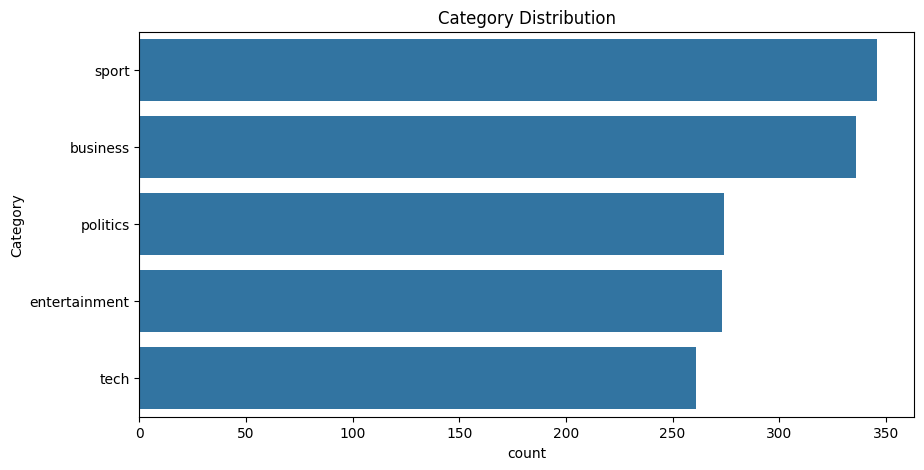

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y=df['Category'], order=df['Category'].value_counts().index)
plt.title("Category Distribution")
plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_content'] = df['Text'].apply(clean_text)

df.head()

,Text,Category,cleaned_content
0,worldcom ex-boss launches defence lawyers defe...,business,worldcom exboss launches defence lawyers defen...
1,german business confidence slides german busin...,business,german business confidence slides german busin...
2,bbc poll indicates economic gloom citizens in ...,business,bbc poll indicates economic gloom citizens maj...
3,lifestyle governs mobile choice faster bett...,tech,lifestyle governs mobile choice faster better ...
4,enron bosses in $168m payout eighteen former e...,business,enron bosses 168m payout eighteen former enron...


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_content'])
y = df['Category']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (1490, 5000)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9664429530201343

Classification Report:

               precision    recall  f1-score   support

     business       0.96      0.97      0.97        75
entertainment       0.98      0.98      0.98        46
     politics       0.96      0.95      0.95        56
        sport       0.95      1.00      0.98        63
         tech       0.98      0.93      0.96        58

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



In [ ]:
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

sample_text = df['Text'].iloc[0]
print(sample_text)
print("\nEntities:")
print(extract_entities(sample_text))

worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  green light  to the procedures and practices used by worldcom. mr ebbe

In [ ]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['Text'].apply(get_sentiment)

df[['Text', 'sentiment']].head()

,Text,sentiment
0,worldcom ex-boss launches defence lawyers defe...,0.023320
1,german business confidence slides german busin...,0.077917
2,bbc poll indicates economic gloom citizens in ...,0.077754
3,lifestyle governs mobile choice faster bett...,0.156109
4,enron bosses in $168m payout eighteen former e...,0.009685


In [ ]:
def analyze_article(article_text):
    cleaned = clean_text(article_text)

    vect = vectorizer.transform([cleaned])

    category = model.predict(vect)[0]

    entities = extract_entities(article_text)

    sentiment = get_sentiment(article_text)

    return {
        "Category": category,
        "Entities": entities,
        "Sentiment": sentiment
    }

new_article = """
Apple announced a new iPhone today in California. The CEO said it will revolutionize the market.
"""

result = analyze_article(new_article)

print(result)

{'Category': 'business', 'Entities': [('Apple', 'ORG'), ('today', 'DATE'), ('California', 'GPE')], 'Sentiment': 0.13636363636363635}
